# Homework 1 - Linear Regression with Gradient Descent

# Data Set Preparation

## Imports

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load the Dataset

In [6]:
data = pd.read_csv("D3.csv")



## Variable Separation & Testing


In [7]:
X1 = data["X1"].to_numpy()
X2 = data["X2"].to_numpy()
X3 = data["X3"].to_numpy()
Y  = data["Y"].to_numpy()

In [8]:
print(len(X1))
print(len(X2))
print(len(X3))
print(len(Y))

100
100
100
100


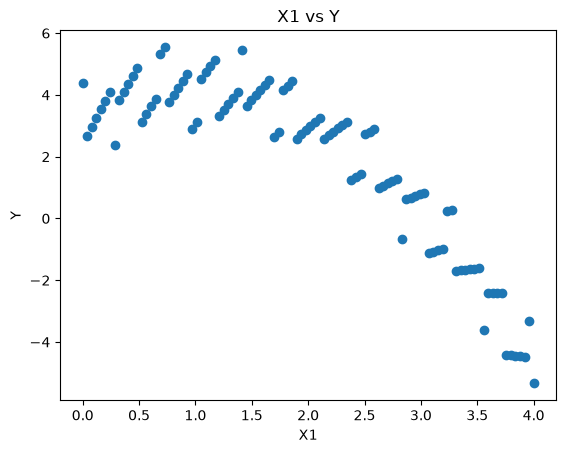

In [9]:
plt.scatter(X1, Y)
plt.xlabel("X1")
plt.ylabel("Y")
plt.title("X1 vs Y")
plt.show()

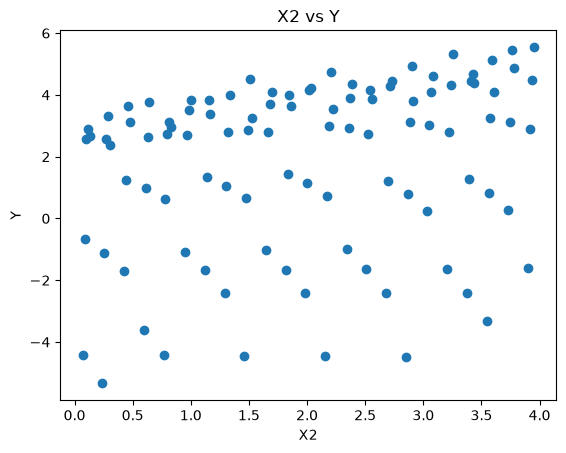

In [10]:
plt.scatter(X2, Y)
plt.xlabel("X2")
plt.ylabel("Y")
plt.title("X2 vs Y")
plt.show()

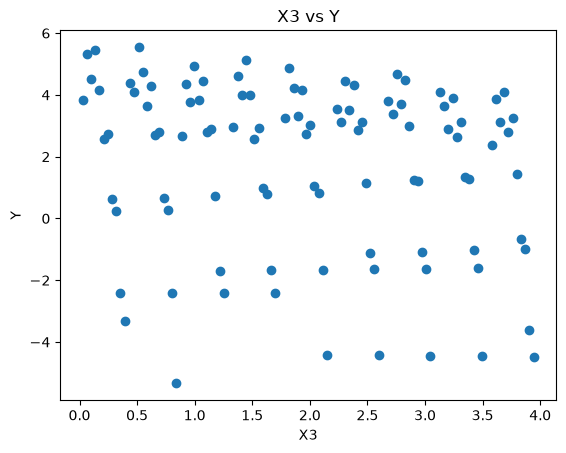

In [11]:
plt.scatter(X3, Y)
plt.xlabel("X3")
plt.ylabel("Y")
plt.title("X3 vs Y")
plt.show()

# Problem 1: Single Variable Linear Regression

## Linear Regression Model

In [12]:
def linear_model(x, theta0, theta1):
  return theta0 + theta1 * x

## Cost Function

In [13]:
def compute_cost(x, y, theta0, theta1):

    m = len(y)

    y_pred = linear_model(x, theta0, theta1)

    error = y_pred - y

    cost = np.sum(error ** 2) / (2 * m)

    return cost

## Gradient Descent

In [14]:
def gradient_descent(x, y, learning_rate, iterations):
    m = len(y)
    theta0 = 0.0
    theta1 = 0.0
    cost_history = []

    for i in range(iterations):

        y_pred = linear_model(x, theta0, theta1)

        error = y_pred - y

        gradient0 = np.sum(error) / m
        gradient1 = np.sum(error * x) / m

        theta0 = theta0 - learning_rate * gradient0
        theta1 = theta1 - learning_rate * gradient1

        cost = compute_cost(x, y, theta0, theta1)
        cost_history.append(cost)

    return theta0, theta1, cost_history

## Training Settings

In [15]:
iterations = 1000
learning_rates = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]

## X1 Linear Regression

In [16]:
x1_theta0 = []
x1_theta1 = []
x1_costs = []

for learning_rate in learning_rates:

    theta0, theta1, cost_history = gradient_descent(X1,Y,learning_rate,iterations)

    x1_theta0.append(theta0)
    x1_theta1.append(theta1)
    x1_costs.append(cost_history)

    print("Learning Rate =", learning_rate)
    print("Theta 0 =", theta0)
    print("Theta 1 =", theta1)
    print("Final Cost =", cost_history[-1])
    print()

Learning Rate = 0.01
Theta 0 = 5.2929472827573
Theta 1 = -1.791190790033247
Final Cost = 1.0364360799429275

Learning Rate = 0.02
Theta 0 = 5.859208469587321
Theta 1 = -2.0115825039221686
Final Cost = 0.9855959214846709

Learning Rate = 0.03
Theta 0 = 5.920544373191543
Theta 1 = -2.0354547473897724
Final Cost = 0.9850000773086248

Learning Rate = 0.04
Theta 0 = 5.927155278592221
Theta 1 = -2.038027745160941
Final Cost = 0.9849931628974796

Learning Rate = 0.05
Theta 0 = 5.927864277730485
Theta 1 = -2.0383036912064445
Final Cost = 0.984993083454563

Learning Rate = 0.06
Theta 0 = 5.927939936519367
Theta 1 = -2.038333137989202
Final Cost = 0.984993082550886

Learning Rate = 0.07
Theta 0 = 5.927947969786956
Theta 1 = -2.0383362645775205
Final Cost = 0.9849930825407093

Learning Rate = 0.08
Theta 0 = 5.927948818448348
Theta 1 = -2.0383365948808203
Final Cost = 0.9849930825405958

Learning Rate = 0.09
Theta 0 = 5.927948907650669
Theta 1 = -2.038336629598814
Final Cost = 0.9849930825405946



## Compare Learning Rates for X1

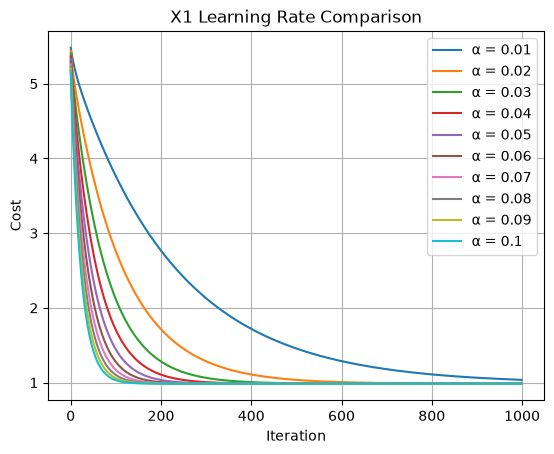

In [17]:
for i in range(len(learning_rates)):
    plt.plot(
        x1_costs[i],
        label=f"α = {learning_rates[i]}"
    )

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("X1 Learning Rate Comparison")

plt.legend()
plt.grid()
plt.show()

## Find the Best X1 Model

In [18]:
final_costs_x1 = []

for cost_history in x1_costs:
    final_costs_x1.append(cost_history[-1])

best_index_x1 = np.argmin(final_costs_x1)

best_rate_x1 = learning_rates[best_index_x1]
best_theta0_x1 = x1_theta0[best_index_x1]
best_theta1_x1 = x1_theta1[best_index_x1]

print("Best Learning Rate:", best_rate_x1)
print("Theta 0:", best_theta0_x1)
print("Theta 1:", best_theta1_x1)
print("Final Cost:", final_costs_x1[best_index_x1])

Best Learning Rate: 0.09
Theta 0: 5.927948907650669
Theta 1: -2.038336629598814
Final Cost: 0.9849930825405946


## Final X1 Regression Plot

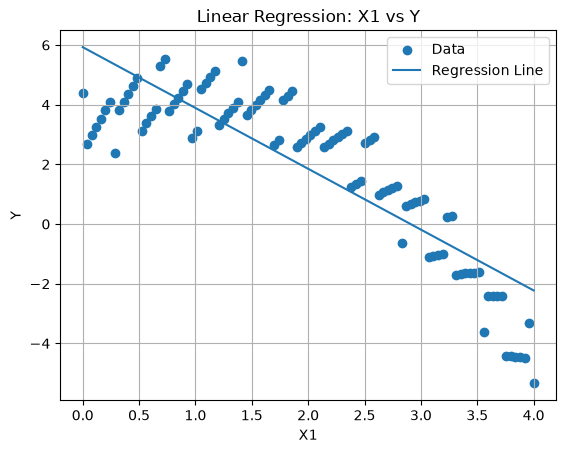

In [19]:
y_pred_x1 = linear_model(X1,best_theta0_x1,best_theta1_x1)

plt.scatter(X1,Y,label="Data")
plt.plot(X1,y_pred_x1,label="Regression Line")

plt.xlabel("X1")
plt.ylabel("Y")
plt.title("Linear Regression: X1 vs Y")

plt.legend()
plt.grid()
plt.show()

## X1 Final Model

In [20]:
print("X1 Final Model")
print("Y =", best_theta0_x1, "+", best_theta1_x1, "* X1")
print("Learning Rate:", best_rate_x1)
print("Final Cost:", final_costs_x1[best_index_x1])

X1 Final Model
Y = 5.927948907650669 + -2.038336629598814 * X1
Learning Rate: 0.09
Final Cost: 0.9849930825405946


## X2 Linear Regression

In [21]:
x2_theta0 = []
x2_theta1 = []
x2_costs = []

for learning_rate in learning_rates:

    theta0, theta1, cost_history = gradient_descent(X2,Y,learning_rate,iterations)

    x2_theta0.append(theta0)
    x2_theta1.append(theta1)
    x2_costs.append(cost_history)

    print("Learning Rate =", learning_rate)
    print("Theta 0 =", theta0)
    print("Theta 1 =", theta1)
    print("Final Cost =", cost_history[-1])
    print()

Learning Rate = 0.01
Theta 0 = 0.6870199464452038
Theta 1 = 0.5766946227869245
Final Cost = 3.5996728289711006

Learning Rate = 0.02
Theta 0 = 0.7307512257200968
Theta 1 = 0.5596740020661444
Final Cost = 3.599369614171041

Learning Rate = 0.03
Theta 0 = 0.7354884870291852
Theta 1 = 0.5578302158944577
Final Cost = 3.599366059899807

Learning Rate = 0.04
Theta 0 = 0.7359991223696033
Theta 1 = 0.5576314718695858
Final Cost = 3.5993660186475456

Learning Rate = 0.05
Theta 0 = 0.7360538911603997
Theta 1 = 0.5576101553467002
Final Cost = 3.5993660181734968

Learning Rate = 0.06
Theta 0 = 0.7360597361604292
Theta 1 = 0.5576078804183134
Final Cost = 3.5993660181681038

Learning Rate = 0.07
Theta 0 = 0.7360603568225246
Theta 1 = 0.5576076388508518
Final Cost = 3.5993660181680425

Learning Rate = 0.08
Theta 0 = 0.7360604223970966
Theta 1 = 0.5576076133286185
Final Cost = 3.599366018168043

Learning Rate = 0.09
Theta 0 = 0.7360604292902085
Theta 1 = 0.5576076106457551
Final Cost = 3.5993660181680

## Compare Learning Rates for X2

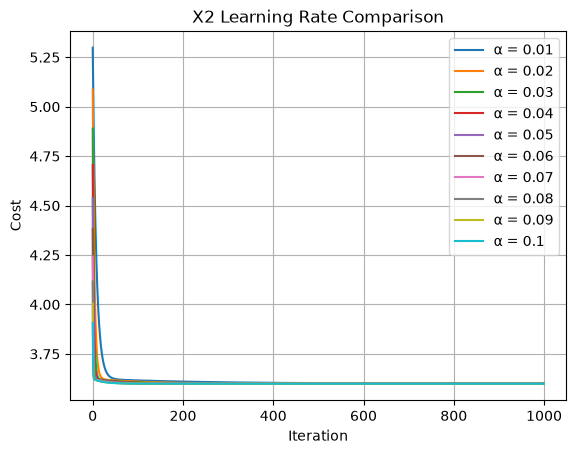

In [22]:
for i in range(len(learning_rates)):
    plt.plot(
        x2_costs[i],
        label=f"α = {learning_rates[i]}"
    )

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("X2 Learning Rate Comparison")

plt.legend()
plt.grid()
plt.show()

## Find the Best X2 Model

In [23]:
final_costs_x2 = []

for cost_history in x2_costs:
    final_costs_x2.append(cost_history[-1])

best_index_x2 = np.argmin(final_costs_x2)

best_rate_x2 = learning_rates[best_index_x2]
best_theta0_x2 = x2_theta0[best_index_x2]
best_theta1_x2 = x2_theta1[best_index_x2]

print("Best Learning Rate:", best_rate_x2)
print("Theta 0:", best_theta0_x2)
print("Theta 1:", best_theta1_x2)
print("Final Cost:", final_costs_x2[best_index_x2])

Best Learning Rate: 0.09
Theta 0: 0.7360604292902085
Theta 1: 0.5576076106457551
Final Cost: 3.5993660181680416


## Final X2 Regression Plot

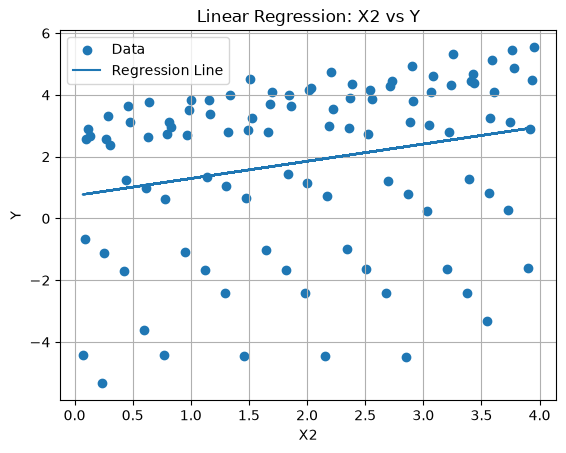

In [24]:
y_pred_x2 = linear_model(X2,best_theta0_x2,best_theta1_x2)

plt.scatter(X2,Y,label="Data")
plt.plot(X2,y_pred_x2,label="Regression Line")

plt.xlabel("X2")
plt.ylabel("Y")
plt.title("Linear Regression: X2 vs Y")

plt.legend()
plt.grid()
plt.show()

## X2 Final Model

In [25]:
print("X2 Final Model")
print("Y =", best_theta0_x2, "+", best_theta1_x2, "* X2")
print("Learning Rate:", best_rate_x2)
print("Final Cost:", final_costs_x2[best_index_x2])

X2 Final Model
Y = 0.7360604292902085 + 0.5576076106457551 * X2
Learning Rate: 0.09
Final Cost: 3.5993660181680416


## X3 Linear Regression

In [26]:
x3_theta0 = []
x3_theta1 = []
x3_costs = []

for learning_rate in learning_rates:

    theta0, theta1, cost_history = gradient_descent(X3,Y,learning_rate,iterations)

    x3_theta0.append(theta0)
    x3_theta1.append(theta1)
    x3_costs.append(cost_history)

    print("Learning Rate =", learning_rate)
    print("Theta 0 =", theta0)
    print("Theta 1 =", theta1)
    print("Final Cost =", cost_history[-1])
    print()

Learning Rate = 0.01
Theta 0 = 2.591186639666167
Theta 1 = -0.4096513504177305
Final Cost = 3.6396602056308045

Learning Rate = 0.02
Theta 0 = 2.8420598533051726
Theta 1 = -0.5088702809869871
Final Cost = 3.6295632022910063

Learning Rate = 0.03
Theta 0 = 2.8683612656699715
Theta 1 = -0.5192723401364803
Final Cost = 3.629452342534862

Learning Rate = 0.04
Theta 0 = 2.8711046606646056
Theta 1 = -0.5203573372692882
Final Cost = 3.6294511377079623

Learning Rate = 0.05
Theta 0 = 2.8713893505679553
Theta 1 = -0.5204699305084965
Final Cost = 3.629451124747377

Learning Rate = 0.06
Theta 0 = 2.8714187419581485
Theta 1 = -0.5204815546363203
Final Cost = 3.6294511246093846

Learning Rate = 0.07
Theta 0 = 2.8714217606748105
Theta 1 = -0.5204827485216084
Final Cost = 3.6294511246079306

Learning Rate = 0.08
Theta 0 = 2.8714220691132413
Theta 1 = -0.5204828705072551
Final Cost = 3.6294511246079155

Learning Rate = 0.09
Theta 0 = 2.8714221004640113
Theta 1 = -0.5204828829063066
Final Cost = 3.6294

## Compare Learning Rates for X3

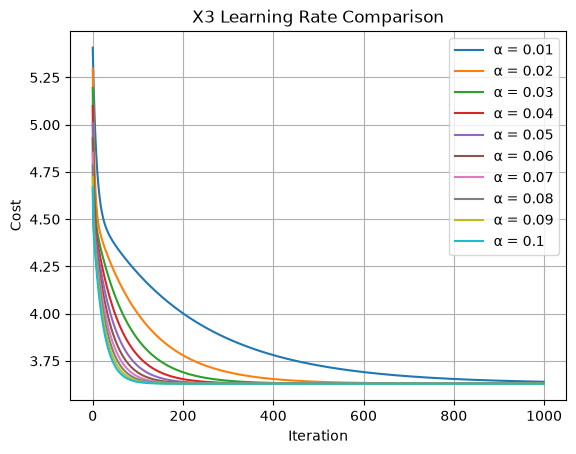

In [27]:
for i in range(len(learning_rates)):
    plt.plot(
        x3_costs[i],
        label=f"α = {learning_rates[i]}"
    )

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("X3 Learning Rate Comparison")

plt.legend()
plt.grid()
plt.show()

## Find the Best X3 Model

In [28]:
final_costs_x3 = []

for cost_history in x3_costs:
    final_costs_x3.append(cost_history[-1])

best_index_x3 = np.argmin(final_costs_x3)

best_rate_x3 = learning_rates[best_index_x3]
best_theta0_x3 = x3_theta0[best_index_x3]
best_theta1_x3 = x3_theta1[best_index_x3]

print("Best Learning Rate:", best_rate_x3)
print("Theta 0:", best_theta0_x3)
print("Theta 1:", best_theta1_x3)
print("Final Cost:", final_costs_x3[best_index_x3])

Best Learning Rate: 0.09
Theta 0: 2.8714221004640113
Theta 1: -0.5204828829063066
Final Cost: 3.629451124607915


## Final X3 Regression Plot

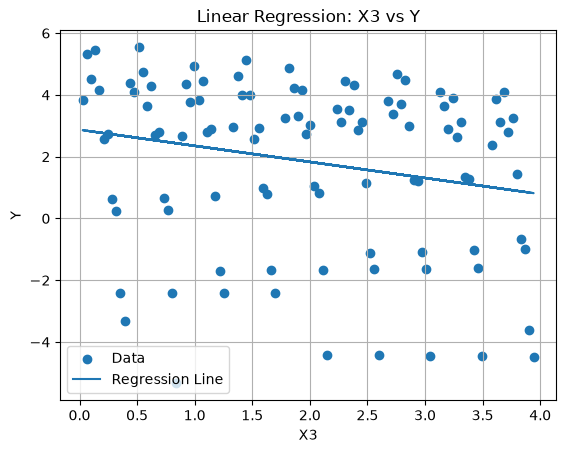

In [29]:
y_pred_x3 = linear_model(X3,best_theta0_x3,best_theta1_x3)

plt.scatter(X3,Y,label="Data")
plt.plot(X3,y_pred_x3,label="Regression Line")

plt.xlabel("X3")
plt.ylabel("Y")
plt.title("Linear Regression: X3 vs Y")

plt.legend()
plt.grid()
plt.show()

## X3 Final Model

In [30]:
print("X3 Final Model")
print("Y =", best_theta0_x3, "+", best_theta1_x3, "* X3")
print("Learning Rate:", best_rate_x3)
print("Final Cost:", final_costs_x3[best_index_x3])

X3 Final Model
Y = 2.8714221004640113 + -0.5204828829063066 * X3
Learning Rate: 0.09
Final Cost: 3.629451124607915


## X1, X2, X3 Comparison

In [31]:
print("X1 Final Cost:",final_costs_x1[best_index_x1])
print("X2 Final Cost:",final_costs_x2[best_index_x2])
print("X3 Final Cost:",final_costs_x3[best_index_x3])

X1 Final Cost: 0.9849930825405946
X2 Final Cost: 3.5993660181680416
X3 Final Cost: 3.629451124607915


# Problem 2: Multiple Variable Linear Regression

In [32]:
X = data[["X1", "X2", "X3"]].to_numpy()

## Multiple Linear Regression Model

In [33]:
def multiple_linear_model(X, theta):

    y_pred = (theta[0] + theta[1] * X[:, 0]
                       + theta[2] * X[:, 1]
                       + theta[3] * X[:, 2])
    return y_pred

## Multiple Linear Regression Cost Function

In [34]:
def compute_multiple_cost(X, Y, theta):
    m = len(Y)
    y_pred = multiple_linear_model(X, theta)
    error = y_pred - Y
    cost = np.sum(error ** 2) / (2 * m)
    return cost

## Multiple Linear Regression Gradient Descent

In [35]:
def multiple_gradient_descent(X, y, learning_rate, iterations):

    m = len(y)
    theta = np.zeros(4)
    cost_history = []

    for i in range(iterations):

        y_pred = multiple_linear_model(X, theta)
        error = y_pred - y

        gradient0 = np.sum(error) / m
        gradient1 = np.sum(error * X[:, 0]) / m
        gradient2 = np.sum(error * X[:, 1]) / m
        gradient3 = np.sum(error * X[:, 2]) / m

        theta[0] = theta[0] - learning_rate * gradient0
        theta[1] = theta[1] - learning_rate * gradient1
        theta[2] = theta[2] - learning_rate * gradient2
        theta[3] = theta[3] - learning_rate * gradient3

        cost = compute_multiple_cost(X, y, theta)
        cost_history.append(cost)

    return theta, cost_history

## Train Multiple Regression with all Learning Rates

In [36]:
multiple_thetas = []
multiple_costs = []

for learning_rate in learning_rates:

    theta, cost_history = multiple_gradient_descent(X,Y,learning_rate,iterations)

    multiple_thetas.append(theta)
    multiple_costs.append(cost_history)

    print("Learning Rate =", learning_rate)
    print("Theta =", theta)
    print("Final Cost =", cost_history[-1])
    print()

Learning Rate = 0.01
Theta = [ 3.39929705 -1.73320582  0.84898275  0.0150737 ]
Final Cost = 0.9337836009440804

Learning Rate = 0.02
Theta = [ 4.60854423 -1.90403835  0.64916316 -0.16217188]
Final Cost = 0.7649865955538009

Learning Rate = 0.03
Theta = [ 5.05440685 -1.96702382  0.57548712 -0.22752628]
Final Cost = 0.7420585248110732

Learning Rate = 0.04
Theta = [ 5.21863739 -1.99022411  0.54834904 -0.25159914]
Final Cost = 0.7389503624202624

Learning Rate = 0.05
Theta = [ 5.27907019 -1.99876124  0.53836289 -0.26045736]
Final Cost = 0.7385298570293828

Learning Rate = 0.06
Theta = [ 5.30128572 -2.00189955  0.53469192 -0.26371371]
Final Cost = 0.7384730804303884

Learning Rate = 0.07
Theta = [ 5.30944412 -2.00305206  0.53334379 -0.26490956]
Final Cost = 0.7384654298325134

Learning Rate = 0.08
Theta = [ 5.31243718 -2.00347488  0.53284921 -0.26534828]
Final Cost = 0.7384644009925565

Learning Rate = 0.09
Theta = [ 5.31353414 -2.00362984  0.53266794 -0.26550908]
Final Cost = 0.7384642629

## Compare Learning Rates for Problem 2

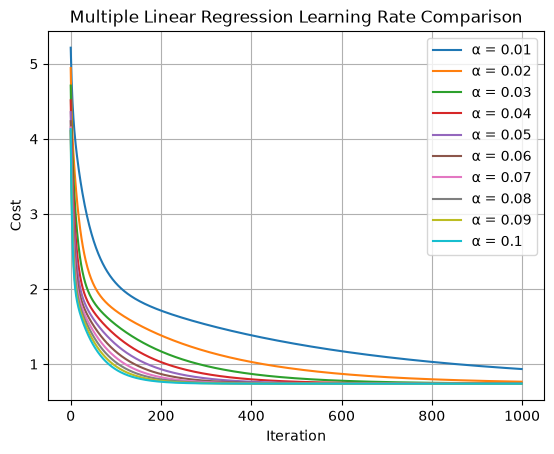

In [37]:
for i in range(len(learning_rates)):

    plt.plot(multiple_costs[i],label=f"α = {learning_rates[i]}")

plt.xlabel("Iteration")
plt.ylabel("Cost")

plt.title("Multiple Linear Regression Learning Rate Comparison")

plt.legend()
plt.grid()
plt.show()

## Find Best Regression Model

In [38]:
final_multiple_costs = []

for cost_history in multiple_costs:
    final_multiple_costs.append(cost_history[-1])

best_index_multiple = np.argmin(final_multiple_costs)

best_rate_multiple = learning_rates[best_index_multiple]

best_theta = multiple_thetas[best_index_multiple]

print("Best Learning Rate:", best_rate_multiple)
print("Theta 0:", best_theta[0])
print("Theta 1:", best_theta[1])
print("Theta 2:", best_theta[2])
print("Theta 3:", best_theta[3])
print("Final Cost:",final_multiple_costs[best_index_multiple])

Best Learning Rate: 0.1
Theta 0: 5.313935769531635
Theta 1: -2.0036865792753904
Theta 2: 0.5326015740310897
Theta 3: -0.26556794655534166
Final Cost: 0.7384642444206544


## Final Loss Plot

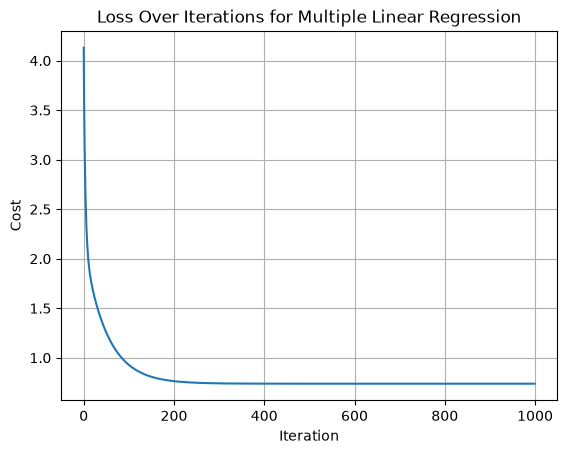

In [39]:
best_cost_history = multiple_costs[best_index_multiple]

plt.plot(best_cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Loss Over Iterations for Multiple Linear Regression")
plt.grid()
plt.show()

## Required Predictions

In [40]:
new_data = np.array([[1, 1, 1],
                     [2, 0, 4],
                     [3, 2, 1]])

predictions = multiple_linear_model(new_data,best_theta)

print("Prediction for (1, 1, 1):",predictions[0])

print("Prediction for (2, 0, 4):",predictions[1])

print("Prediction for (3, 2, 1):",predictions[2])

Prediction for (1, 1, 1): 3.5772828177319926
Prediction for (2, 0, 4): 0.24429082475948727
Prediction for (3, 2, 1): 0.10251123321230116


# Problem 1 Results Table

In [41]:
results = pd.DataFrame({"Learning Rate": learning_rates,
                        "X1 Final Cost": final_costs_x1,
                        "X2 Final Cost": final_costs_x2,
                        "X3 Final Cost": final_costs_x3})
results

,Learning Rate,X1 Final Cost,X2 Final Cost,X3 Final Cost
0,0.01,1.036436,3.599673,3.639660
1,0.02,0.985596,3.599370,3.629563
2,0.03,0.985000,3.599366,3.629452
3,0.04,0.984993,3.599366,3.629451
4,0.05,0.984993,3.599366,3.629451
5,0.06,0.984993,3.599366,3.629451
6,0.07,0.984993,3.599366,3.629451
7,0.08,0.984993,3.599366,3.629451
8,0.09,0.984993,3.599366,3.629451
9,0.10,0.984993,3.599366,3.629451


# Problem 2 Results Table

In [42]:
multiple_results = pd.DataFrame({"Learning Rate": learning_rates,
                                 "Final Cost": final_multiple_costs})
multiple_results

,Learning Rate,Final Cost
0,0.01,0.933784
1,0.02,0.764987
2,0.03,0.742059
3,0.04,0.738950
4,0.05,0.738530
5,0.06,0.738473
6,0.07,0.738465
7,0.08,0.738464
8,0.09,0.738464
9,0.10,0.738464


# Summary of Results

## Problem 1

Linear regression was performed independently using X1, X2, and X3.

The learning rates tested were:

0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, and 0.10.

The final regression models and costs are reported above.

The explanatory variable with the lowest final cost provides the best individual linear fit for Y.

## Problem 2

Multiple linear regression was performed using X1, X2, and X3 together.

The same range of learning rates was tested.

The final model was selected based on the lowest observed cost, and the model was used to predict Y for the three requested input combinations.